# Banknote dimensions

Which banknotes exhibit the greatest size differences between denominations? Which are the largest overall?

Banknote dimensions differ widely across countries.

The size of a banknote impacts its practicality. Uniform dimensions enhance durability by ensuring a snug wallet fit, while also enabling vending machines and ATMs to process them seamlessly. Conversely, varied sizes assist the visually impaired in distinguishing denominations, though smaller notes can pose challenges for machine sorting and counting.

Striking a balance between these considerations is essential in currency design.

The file `banknote-dimensions.csv` shows the `length` and `width` in millimeters for 42 currencies. This dataset spans all 22 subregions and sub-subregions of the world, as defined by the United Nations Statistics Division's geoscheme.

In [2]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'banknote-dimensions.csv'.

# from google.colab import files
# uploaded = files.upload()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('banknote-dimensions.csv')
df

,currency,code,value,length,width
0,Argentine Peso,ARS,2,155.0,65.0
1,Argentine Peso,ARS,5,155.0,65.0
2,Argentine Peso,ARS,10,155.0,65.0
3,Argentine Peso,ARS,20,155.0,65.0
4,Argentine Peso,ARS,50,155.0,65.0
...,...,...,...,...,...
245,West African Franc,XOF,500,114.0,60.0
246,West African Franc,XOF,1000,125.0,66.0
247,West African Franc,XOF,2000,130.0,65.0
248,West African Franc,XOF,5000,140.0,74.0


In [27]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
length = df.groupby('currency').agg(max=('length', 'max'), min=('length', 'min')).reset_index()
length['diff'] = length['max'] - length['min']
length = length.sort_values(by='diff', ascending=False)
longest = length.head(3)
length.head()

,currency,max,min,diff
2,Bangladeshi Taka,155.0,100.0,55.0
14,Euro,160.0,120.0,40.0
22,Kyrgystani Som,156.0,120.0,36.0
10,Costa Rican Colon,160.0,125.0,35.0
35,Swedish Krona,154.0,120.0,34.0


In [32]:
# longest and shortest banknotes for each currency
# modify the code below if you are more interested in width
width = df.groupby('currency').agg(max=('width', 'max'), min=('width', 'min')).reset_index()
width['diff'] = width['max'] - width['min']
widest = width.head(3)
width.head()

,currency,max,min,diff
0,Argentine Peso,65.00,65.00,0.0
1,Australian Dollar,72.50,65.00,7.5
2,Bangladeshi Taka,65.00,60.00,5.0
3,Bolivian Boliviano,70.00,70.00,0.0
4,Canadian Dollar,69.85,69.85,0.0


In [23]:
# helper function, change gap, vertical alignment, horizontal alignment, placement of gap...
def add_labels(df, x_col, y_col, label_col):
	for i, row in df.iterrows():
		x = row[x_col]
		y = row[y_col]
		gap = "  "
		label = gap + row[label_col]
		plt.text(x, y, label, va='center', ha='left')

### Project Ideas

- Generate paired scatter plots to compare the `length` of the longest and shortest banknotes for each currency.

- Create similar paired scatter plots, but for `width` instead of `length`.

- Incorporate the Pro Tips into your visualizations.

- Add labels to data points to highlight key insights or narrate a compelling story.

- Calculate the percentage of currencies where:
	- Only the `length` remains consistent across all denominations.
	- Only the `width` remains consistent across all denominations.
	- Both `length` and `width` vary with denominations.
	- All denominations share identical `length` and `width` dimensions.

- Visualize these findings in a clear, engaging format.

Below is a preliminary paired scatter plot of banknote length to serve as a starting point.

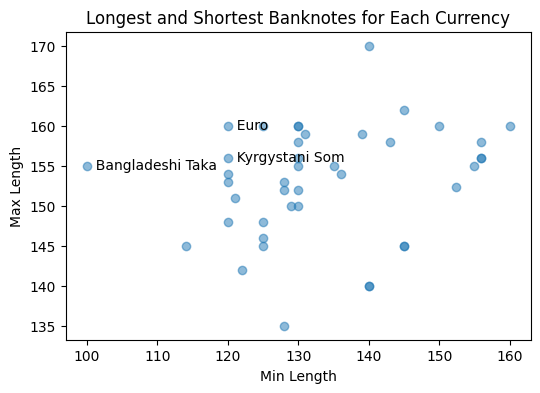

In [30]:
plt.figure(figsize=(6, 4))  
plt.scatter(length['min'], length['max'], alpha=0.5)
plt.xlabel('Min Length')
plt.ylabel('Max Length')
plt.title('Longest and Shortest Banknotes for Each Currency')
add_labels(longest, 'min', 'max', 'currency')
plt.show()

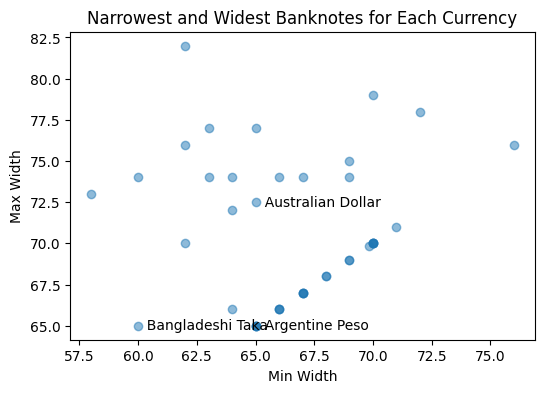

In [34]:
plt.figure(figsize=(6, 4))  
plt.scatter(width['min'], width['max'], alpha=0.5)
plt.xlabel('Min Width')
plt.ylabel('Max Width')
plt.title('Narrowest and Widest Banknotes for Each Currency')
add_labels(widest, 'min', 'max', 'currency')
plt.show()

In [ ]:
# length remains consistent
same_length = length.query('diff == 0')
same_length

,currency,max,min,diff
27,Peruvian Sol,140.0,140.0,0.0
31,Philippine Piso,160.0,160.0,0.0
19,Jamaican Dollar,145.0,145.0,0.0
13,East Caribbean Dollar,145.0,145.0,0.0
4,Canadian Dollar,152.4,152.4,0.0
38,US Dollar,156.0,156.0,0.0
3,Bolivian Boliviano,140.0,140.0,0.0
40,Venezuelan Bolivar,156.0,156.0,0.0
0,Argentine Peso,155.0,155.0,0.0


In [ ]:
# width remains consistent
same_width = width.query('diff == 0')
same_width

,currency,max,min,diff
0,Argentine Peso,65.00,65.00,0.0
3,Bolivian Boliviano,70.00,70.00,0.0
4,Canadian Dollar,69.85,69.85,0.0
7,Chilean Peso,70.00,70.00,0.0
9,Colombian Peso,66.00,66.00,0.0
10,Costa Rican Colon,67.00,67.00,0.0
12,Dobra,67.00,67.00,0.0
13,East Caribbean Dollar,69.00,69.00,0.0
16,Icelandic Krona,70.00,70.00,0.0
17,Indonesian Rupiah,65.00,65.00,0.0


In [48]:
# both length and width vary
diff_length = length.query('diff != 0')
diff_width = width.query('diff != 0')
diff_length_width = pd.merge(diff_length, diff_width, how='inner', on='currency')
diff_length_width

,currency,max_x,min_x,diff_x,max_y,min_y,diff_y
0,Bangladeshi Taka,155.0,100.0,55.0,65.0,60.0,5.0
1,Euro,160.0,120.0,40.0,82.0,62.0,20.0
2,Kyrgystani Som,156.0,120.0,36.0,73.0,58.0,15.0
3,West African Franc,145.0,114.0,31.0,74.0,60.0,14.0
4,Turkish Lira,160.0,130.0,30.0,72.0,64.0,8.0
5,Ukrainian Hryvna,160.0,130.0,30.0,75.0,69.0,6.0
6,Czech Koruna,170.0,140.0,30.0,74.0,69.0,5.0
7,Australian Dollar,158.0,130.0,28.0,72.5,65.0,7.5
8,Serbian Dinar,159.0,131.0,28.0,76.0,62.0,14.0
9,Chinese Yuan,155.0,130.0,25.0,77.0,63.0,14.0


In [ ]:
# both length and width remains consistent
same_length_width = pd.merge(same_length, same_width, how='inner', on='currency')
same_length_width

,currency,max_x,min_x,diff_x,max_y,min_y,diff_y
0,Peruvian Sol,140.0,140.0,0.0,65.00,65.00,0.0
1,Philippine Piso,160.0,160.0,0.0,66.00,66.00,0.0
2,Jamaican Dollar,145.0,145.0,0.0,68.00,68.00,0.0
3,East Caribbean Dollar,145.0,145.0,0.0,69.00,69.00,0.0
4,Canadian Dollar,152.4,152.4,0.0,69.85,69.85,0.0
5,US Dollar,156.0,156.0,0.0,67.00,67.00,0.0
6,Bolivian Boliviano,140.0,140.0,0.0,70.00,70.00,0.0
7,Venezuelan Bolivar,156.0,156.0,0.0,69.00,69.00,0.0
8,Argentine Peso,155.0,155.0,0.0,65.00,65.00,0.0
